### Analyse univariée des variables

Nous allons etudier notre base de données "df_imputation" après les traitements effectués

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
df_imputation_provisoire = pd.read_csv("data/df_imputation.csv")

/tmp/ipykernel_12630/3693561673.py:1: DtypeWarning: Columns (0: CODGEO, 1: Libellé géographique) have mixed types. Specify dtype option on import or set low_memory=False.
  df_imputation_provisoire = pd.read_csv("data/df_imputation.csv")


In [8]:
print(df_imputation_provisoire.shape)
print(df_imputation_provisoire.columns)

(35206, 23)
Index(['CODGEO', 'NB_VP', 'NB_VP_RECHARGEABLES_EL', 'taux_equipement_ve',
       'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs',
       'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb',
       'pct_paiement_autre', 'pct_charge_rapide', 'top_operateur', 'prive',
       'public', 'rapide', 'voirie', 'Libellé géographique',
       '[DISP] Médiane (€)', '[DISP] Nbre de ménages fiscaux',
       '[DISP] Nbre de personnes dans les ménages fiscaux'],
      dtype='str')


In [9]:
missing = pd.DataFrame({
    "nb_manquants": df_imputation_provisoire.isna().sum(),
    "pct_manquants": (df_imputation_provisoire.isna().mean() * 100).round(2)
})

missing.sort_values("nb_manquants", ascending=False)

,nb_manquants,pct_manquants
[DISP] Nbre de ménages fiscaux,15850,45.02
[DISP] Médiane (€),15850,45.02
[DISP] Nbre de personnes dans les ménages fiscaux,15850,45.02
Libellé géographique,13818,39.25
CODGEO,0,0.00
NB_VP,0,0.00
NB_VP_RECHARGEABLES_EL,0,0.00
puissance_max,0,0.00
puissance_moyenne,0,0.00
total_pdc,0,0.00


Certaines variables socio-économiques, telles que l’indice de Gini ou la structure des revenus, présentent un intérêt théorique élevé pour expliquer le taux d’équipement en véhicules électriques.
Toutefois, leur taux de valeurs manquantes étant supérieur à 85%, leur utilisation aurait conduit à une réduction significative de la taille de l’échantillon et à un risque de biais de sélection.
Elles ont donc été exclues de l’analyse principale, mais peuvent faire l’objet d’analyses complémentaires sur un sous-échantillon restreint.

In [10]:
#df_imputation = df_imputation_provisoire.copy()
#df_imputation = df_imputation.drop(columns=vars_to_drop_1)

In [11]:
print(df_imputation.shape)
print(df_imputation.columns)

(35206, 23)
Index(['CODGEO', 'NB_VP', 'NB_VP_RECHARGEABLES_EL', 'taux_equipement_ve',
       'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs',
       'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb',
       'pct_paiement_autre', 'pct_charge_rapide', 'top_operateur', 'prive',
       'public', 'rapide', 'voirie', 'Libellé géographique',
       '[DISP] Médiane (€)', '[DISP] Nbre de ménages fiscaux',
       '[DISP] Nbre de personnes dans les ménages fiscaux'],
      dtype='str')


Analysons notre variable cible "taux_equipement_ve"

In [12]:
target = "taux_equipement_ve"
print(df_imputation[target].describe())

count    35206.000000
mean         0.022886
std          0.018198
min          0.000000
25%          0.012821
50%          0.020548
75%          0.030189
max          1.000000
Name: taux_equipement_ve, dtype: float64


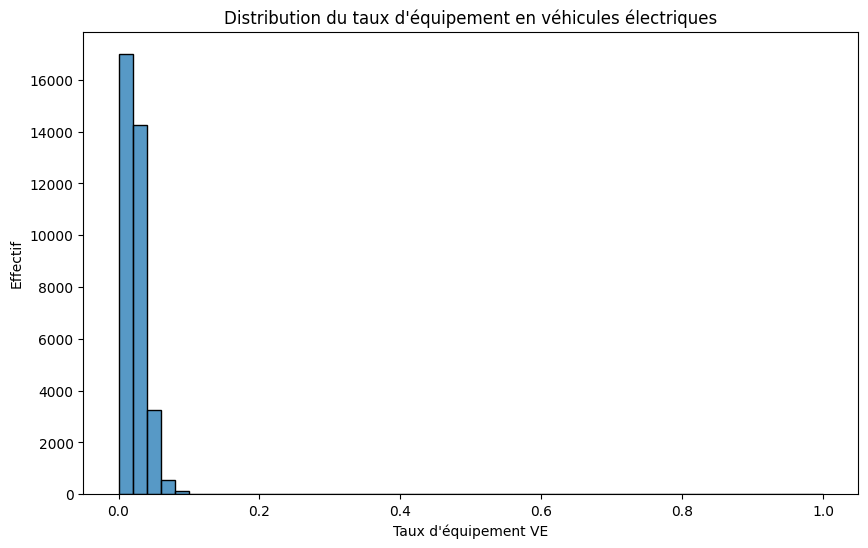

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df_imputation[target], bins=50)
plt.title("Distribution du taux d'équipement en véhicules électriques")
plt.xlabel("Taux d'équipement VE")
plt.ylabel("Effectif")
plt.show()

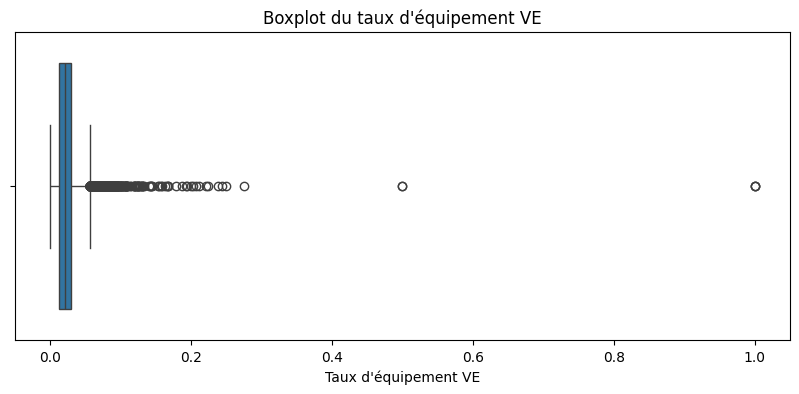

In [14]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_imputation[target])
plt.title("Boxplot du taux d'équipement VE")
plt.xlabel("Taux d'équipement VE")
plt.show()

Le boxplot met en évidence une distribution fortement asymétrique à droite du taux d’équipement en véhicules électriques.
La majorité des communes présentent des taux faibles, tandis qu’un nombre limité d’observations affiche des valeurs élevées, générant de nombreux points extrêmes.
Ces valeurs élevées ne traduisent pas nécessairement des anomalies, mais peuvent s’expliquer par des effets de petite taille de population ou par des spécificités territoriales.
Afin de limiter l’influence de ces observations sur la modélisation, une transformation logarithmique de la variable cible sera envisagée.

In [15]:
#df_imputation["log_taux_equipement_ve"] = np.log1p(df_imputation["taux_equipement_ve"])

## Analyse des variables explicatives

In [16]:
# Variables à exclure (identifiants / non pertinentes)
cols_to_exclude = ["CODGEO", "Libellé géographique", target]

# Variables numériques explicatives
num_cols = [
    col for col in df_imputation.select_dtypes(include=["number"]).columns
    if col not in cols_to_exclude
]

# Variables qualitatives
cat_cols = [
    col for col in df_imputation.select_dtypes(include=["object"]).columns
    if col not in ["CODGEO", "Libellé géographique"]
]

print("Variables numériques :", num_cols)
print("\nVariables qualitatives :", cat_cols)

Variables numériques : ['NB_VP', 'NB_VP_RECHARGEABLES_EL', 'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs', 'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb', 'pct_paiement_autre', 'pct_charge_rapide', 'prive', 'public', 'rapide', 'voirie', '[DISP] Médiane (€)', '[DISP] Nbre de ménages fiscaux', '[DISP] Nbre de personnes dans les ménages fiscaux']

Variables qualitatives : ['top_operateur']


/tmp/ipykernel_12630/2953971799.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df_imputation.select_dtypes(include=["object"]).columns


Regardons si des variables numériques ont peu de modalités alors nous pouvons les considérer comme qualitatives :

In [17]:
df_imputation.nunique().sort_values()

nb_operateurs                                           37
puissance_max                                          101
top_operateur                                          158
rapide                                                 474
pct_paiement_autre                                     484
public                                                 514
pct_type_ef                                            558
pct_paiement_cb                                        588
voirie                                                 595
prive                                                  612
pct_charge_rapide                                      612
pct_combo_ccs                                          626
pct_type_2                                             634
total_pdc                                              660
NB_VP_RECHARGEABLES_EL                                1004
[DISP] Médiane (€)                                    1831
puissance_moyenne                                     19

Nous gardons les variables ainsi

Analyse univariée des variables numériques

In [18]:
desc = df_imputation[num_cols].describe().T

desc["missing_pct"] = df_imputation[num_cols].isna().mean() * 100
desc["skewness"] = df_imputation[num_cols].skew()

display(desc.sort_values("missing_pct", ascending=False))

,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness
[DISP] Nbre de ménages fiscaux,19356.0,1006.244110,4438.451795,36.0,114.0,242.0,603.25,222023.0,45.020735,20.142149
[DISP] Médiane (€),19356.0,23349.973652,3230.531403,13280.0,21340.0,22880.0,24830.00,54120.0,45.020735,1.504950
[DISP] Nbre de personnes dans les ménages fiscaux,19356.0,2244.563391,9152.663422,78.0,260.0,567.0,1408.00,420447.0,45.020735,17.722967
total_pdc,35206.0,27.652843,665.765527,0.0,0.0,0.0,0.00,104751.0,0.000000,118.198819
NB_VP_RECHARGEABLES_EL,35206.0,64.246151,395.328601,0.0,4.0,11.0,34.00,31298.0,0.000000,32.402890
NB_VP,35206.0,2028.941601,7936.071844,1.0,247.0,550.0,1356.75,415083.0,0.000000,17.608545
puissance_moyenne,35206.0,9.456583,105.366762,0.0,0.0,0.0,0.00,7360.0,0.000000,49.203868
pct_combo_ccs,35206.0,0.032927,0.132587,0.0,0.0,0.0,0.00,1.0,0.000000,4.486804
puissance_max,35206.0,24.318944,382.918811,0.0,0.0,0.0,0.00,50000.0,0.000000,72.647460
nb_operateurs,35206.0,0.420639,1.583071,0.0,0.0,0.0,0.00,41.0,0.000000,8.836926


La base présente des distributions très asymétriques avec de nombreux zéros et quelques valeurs extrêmes, ce qui rend les moyennes peu représentatives. Cela traduit un fort effet de taille entre petites communes et grandes villes, qui risque de dominer l’analyse. Les variables liées aux infrastructures sont très peu renseignées (souvent nulles), tandis que les variables socio-économiques comportent près de 45 % de valeurs manquantes. Dans l’ensemble, la base nécessite des transformations (log, ratios) et une attention particulière aux biais liés à la taille et aux données manquantes avant toute modélisation.

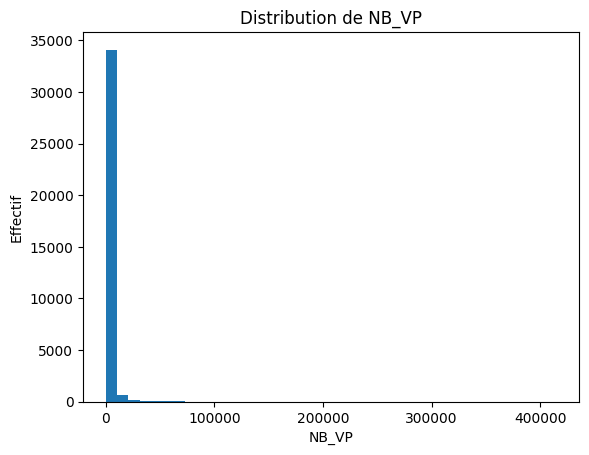

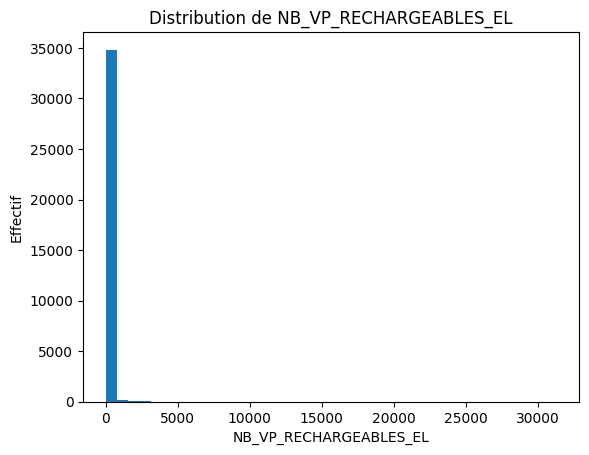

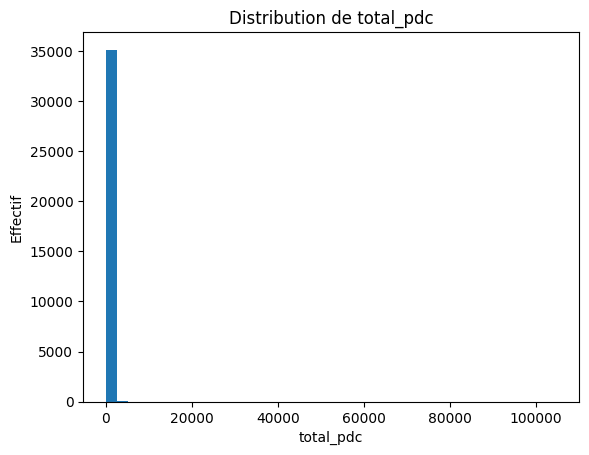

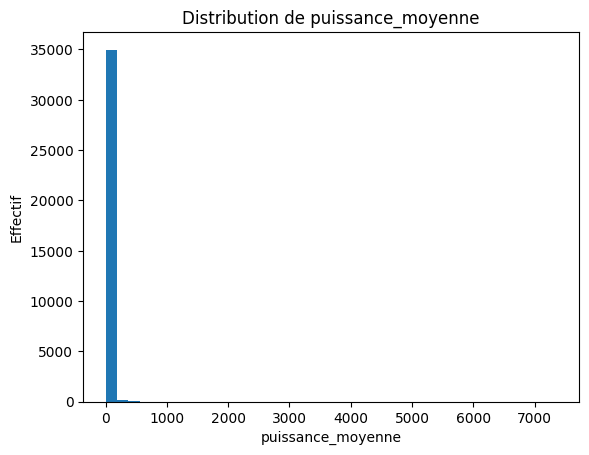

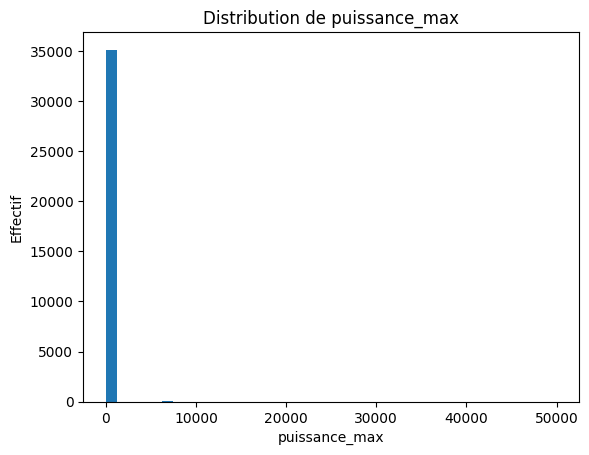

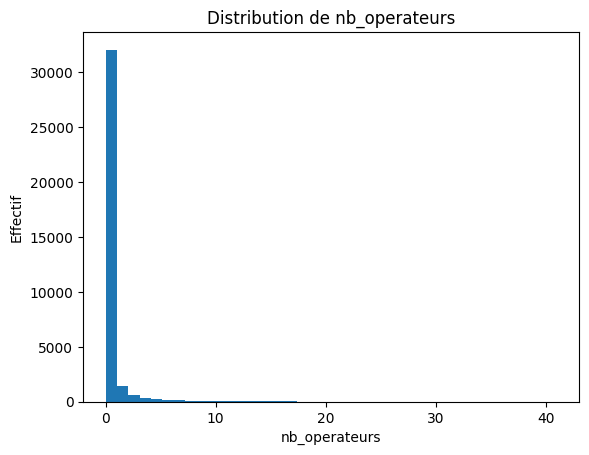

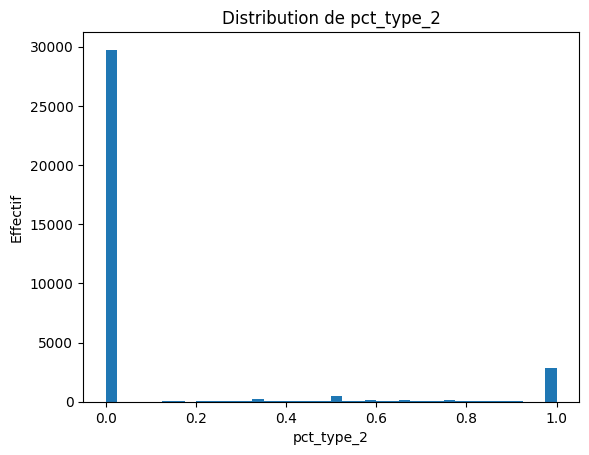

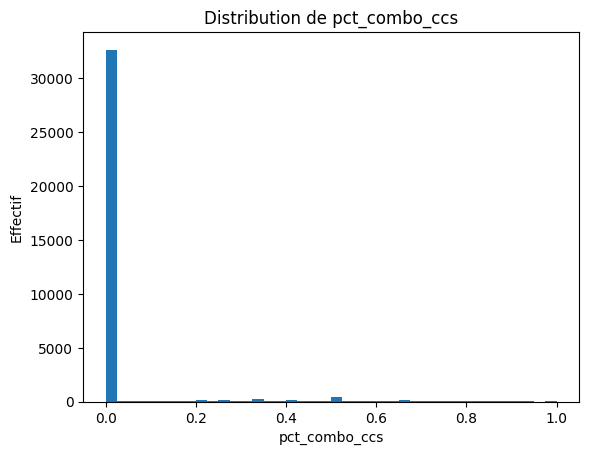

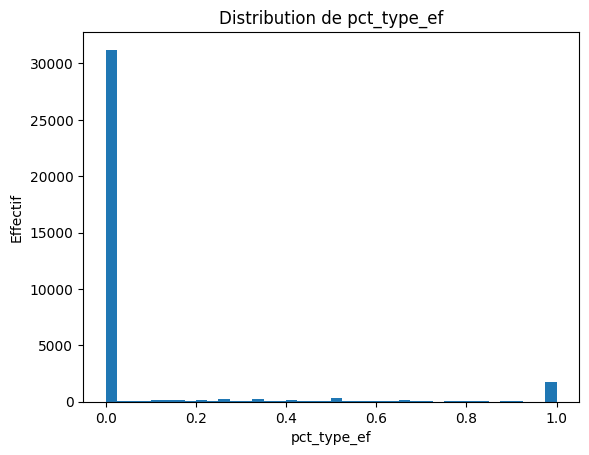

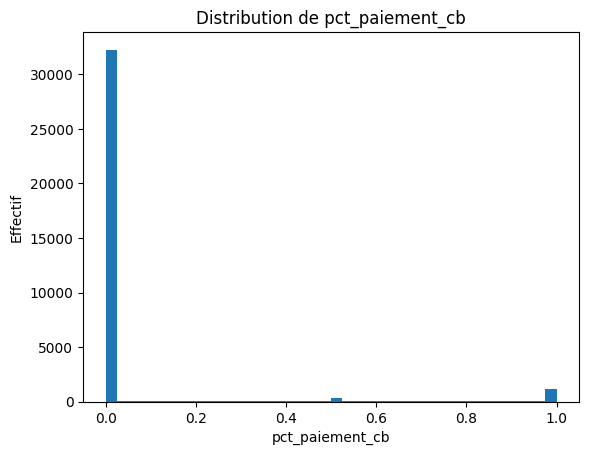

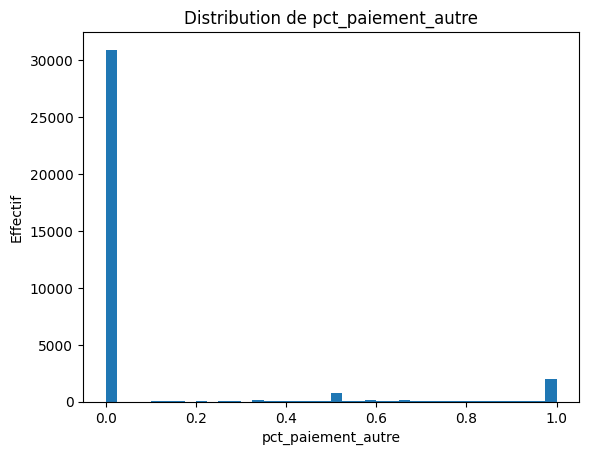

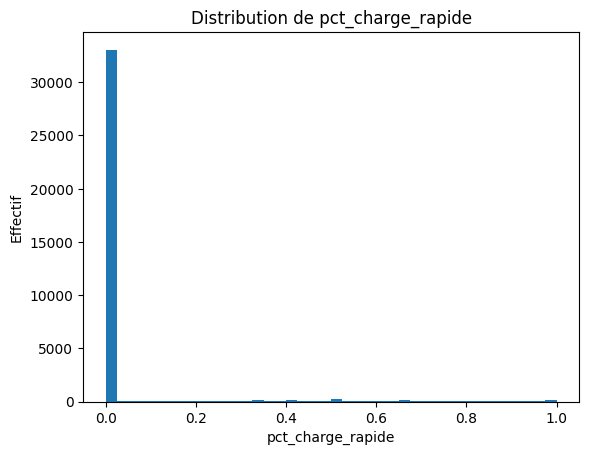

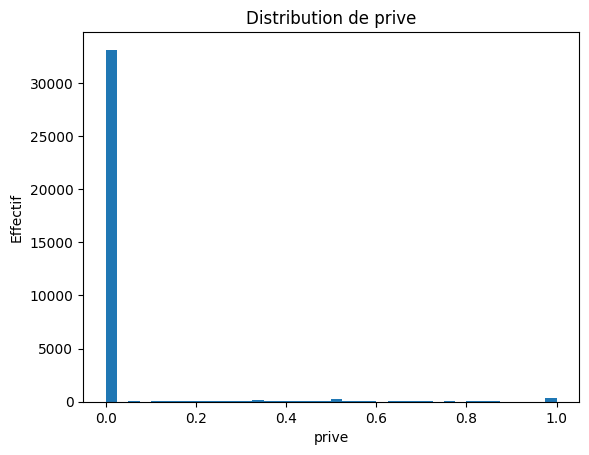

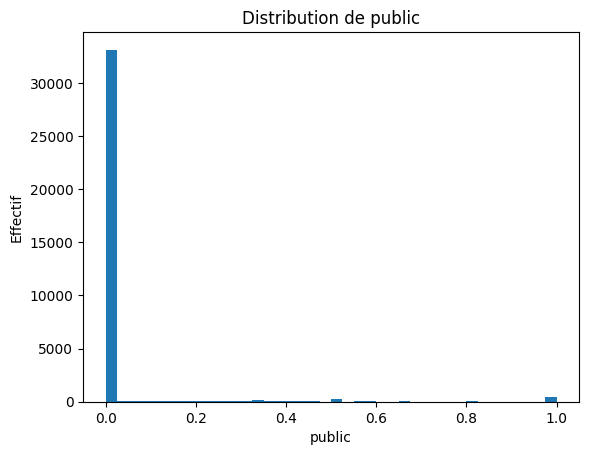

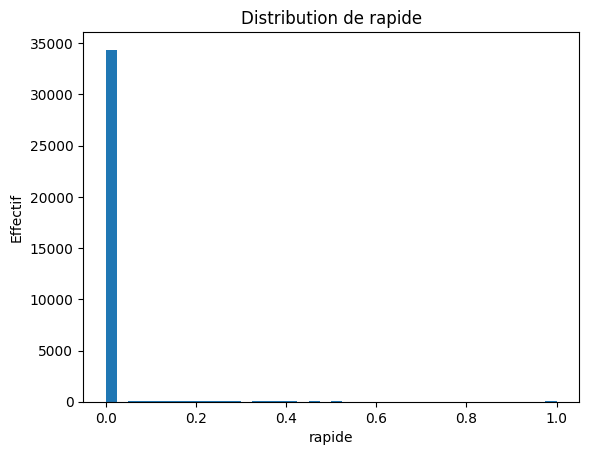

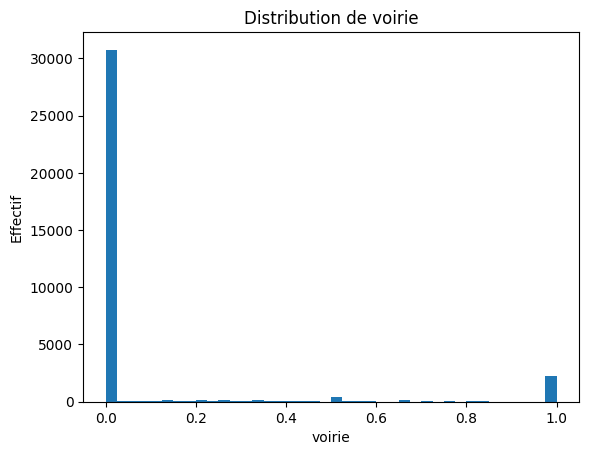

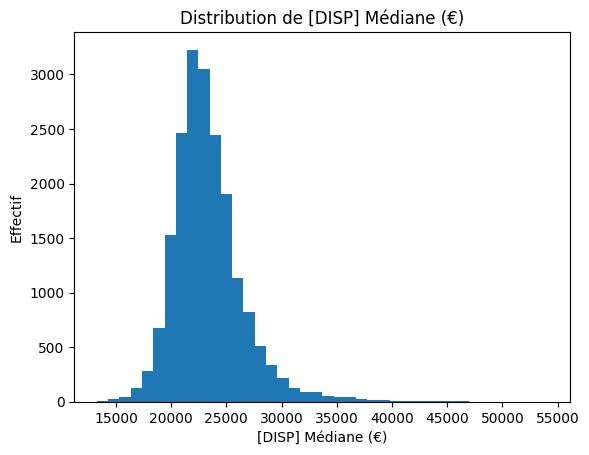

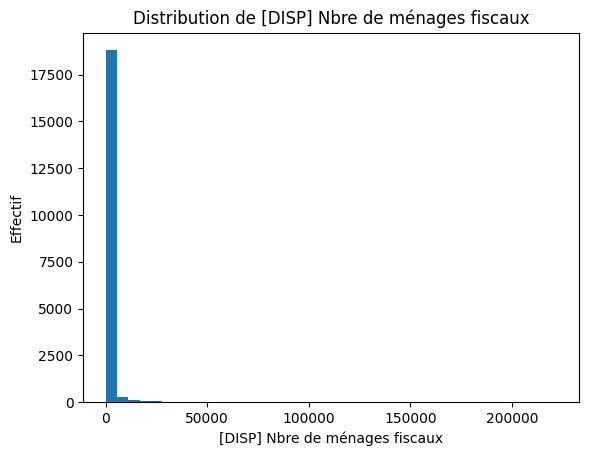

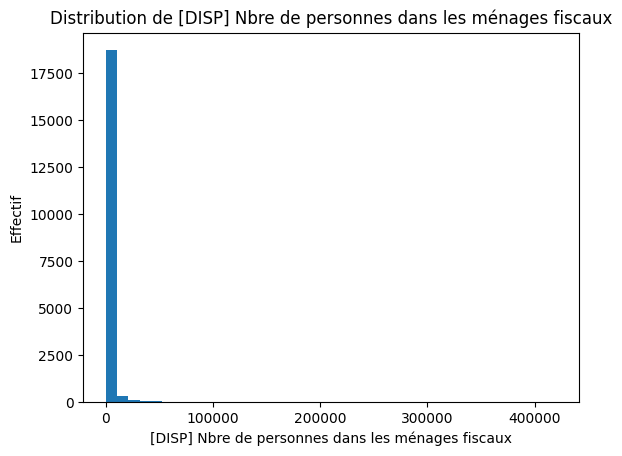

In [19]:
for col in num_cols:
    plt.figure()
    plt.hist(df_imputation[col].dropna(), bins=40)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.show()

### Analyse univariée des variables qualitatives

In [20]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    display(df_imputation[col].value_counts(dropna=False))


--- top_operateur ---


top_operateur
Aucun                           29649
Bouygues Energies & Services      981
EASYCHARGE                        407
Freshmile | FR*FR1                387
inconnu                           363
                                ...  
Fuzed | FR*FZD                      1
AUTORECHARGE SAS                    1
Séolis                              1
Normatech                           1
LUMI'IN                             1
Name: count, Length: 158, dtype: int64

Cette variable risque d'être retravaillée car beaucoup de NA et importance avec la variable cible

### Analyses bivariées avec la cible

Variables numériques vs cible

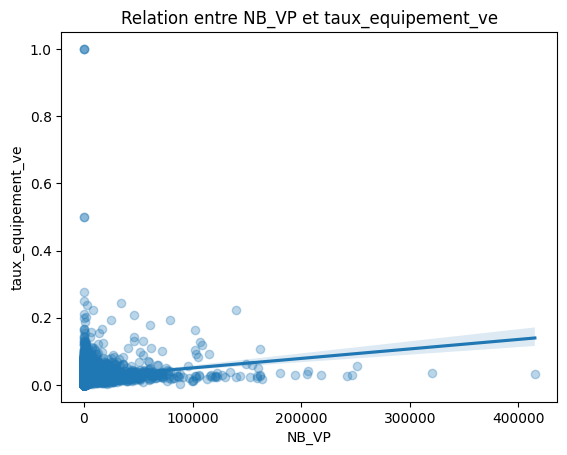

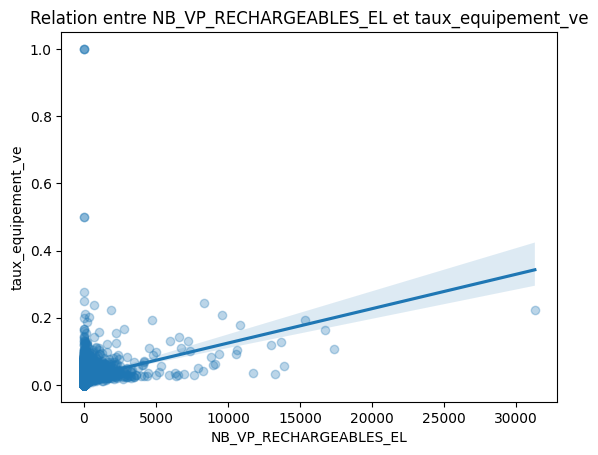

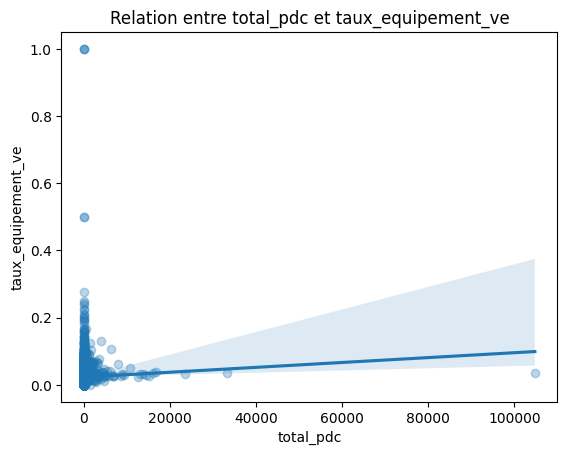

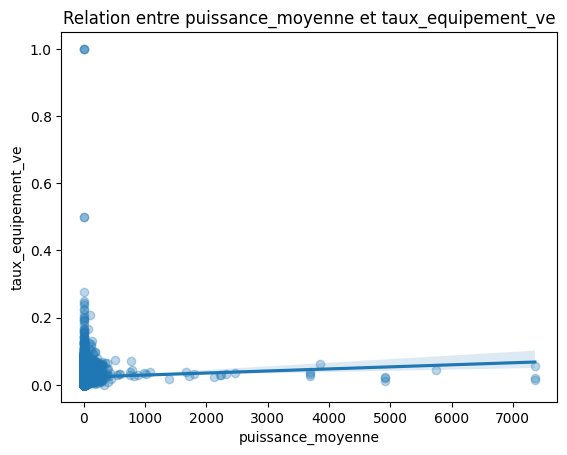

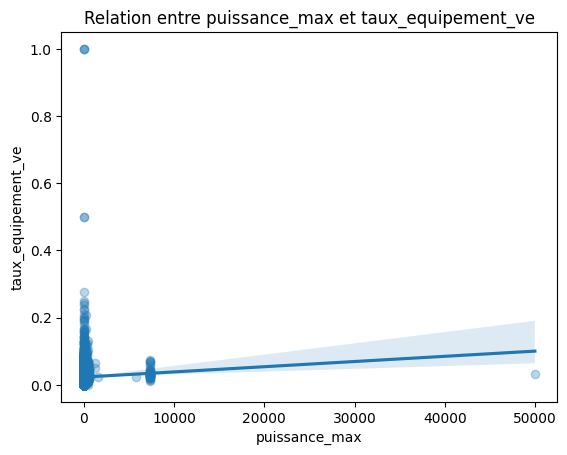

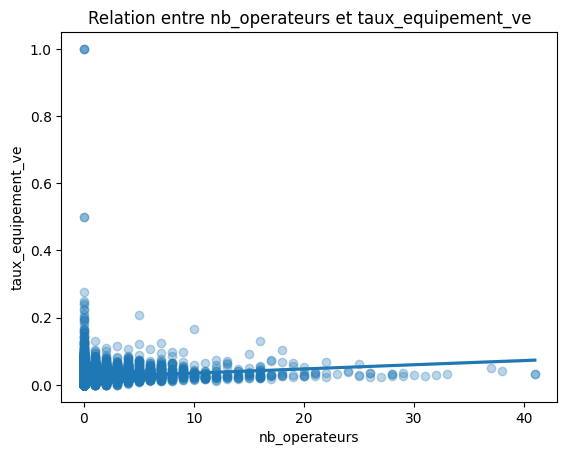

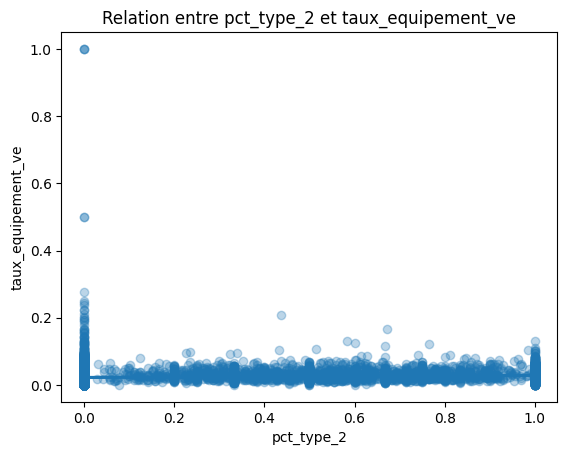

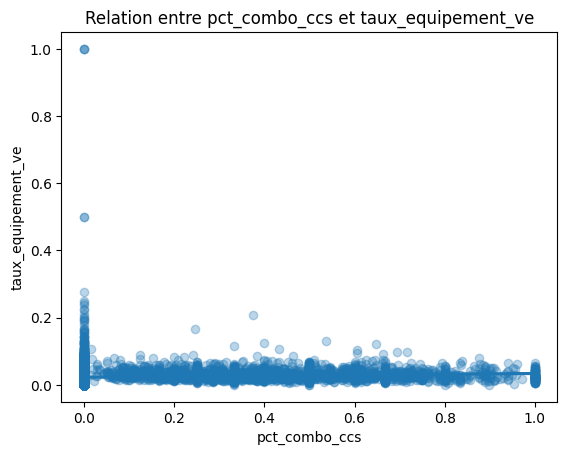

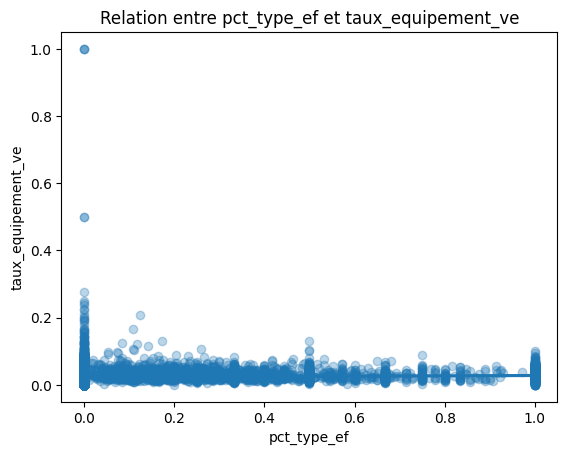

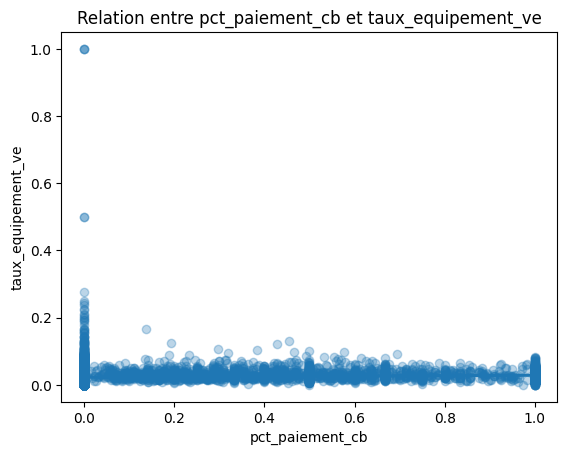

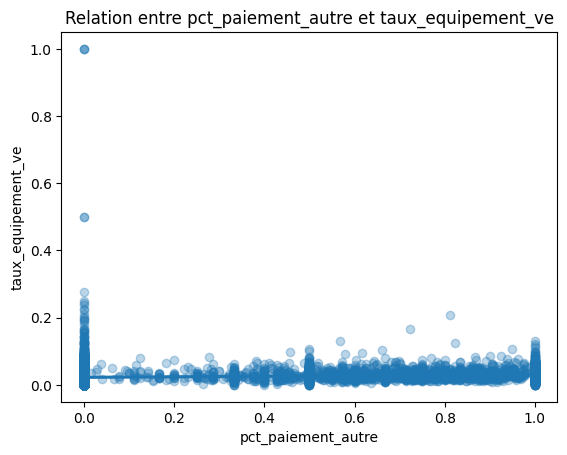

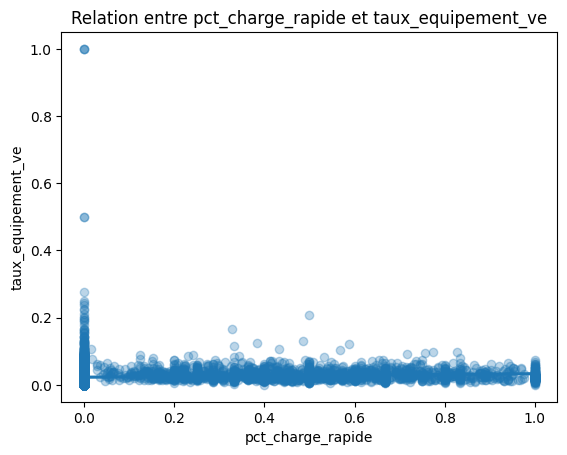

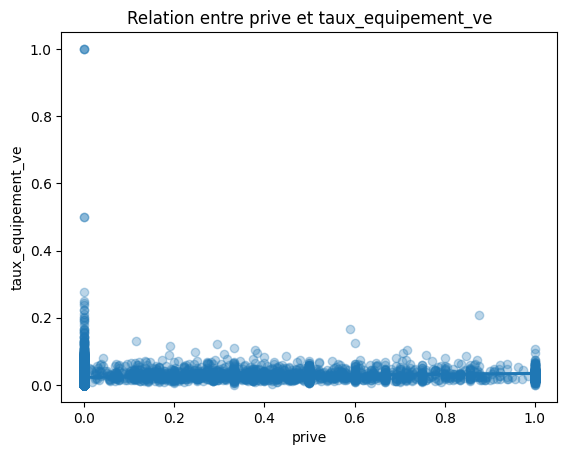

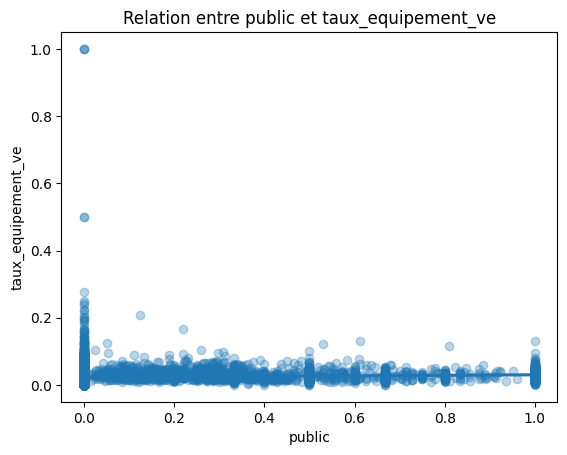

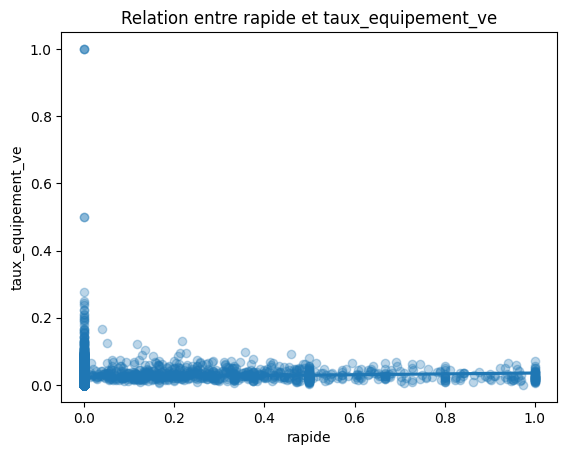

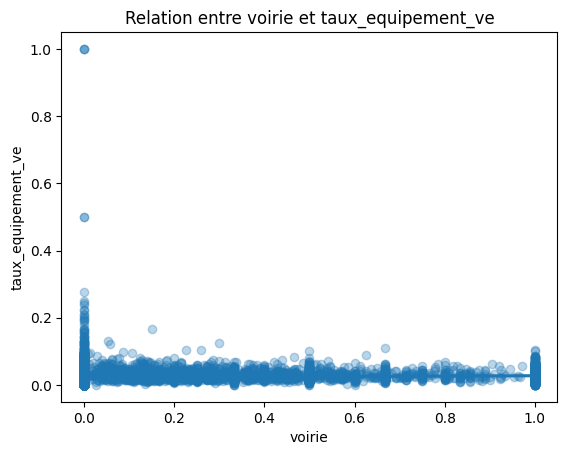

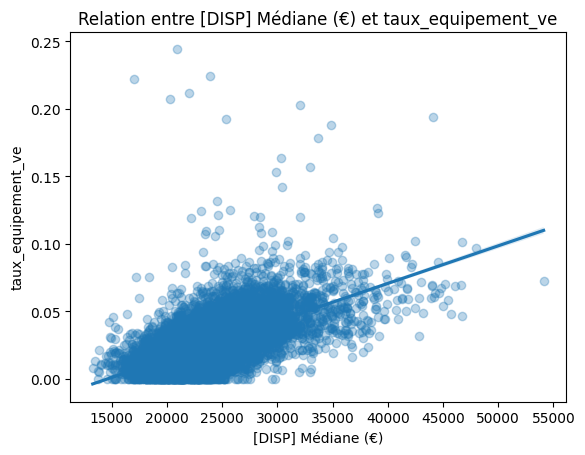

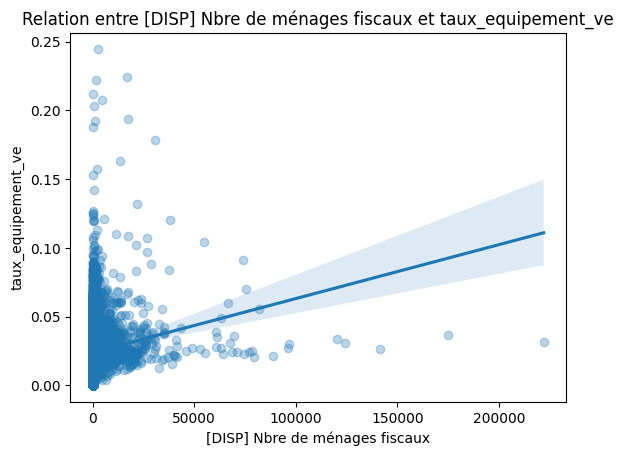

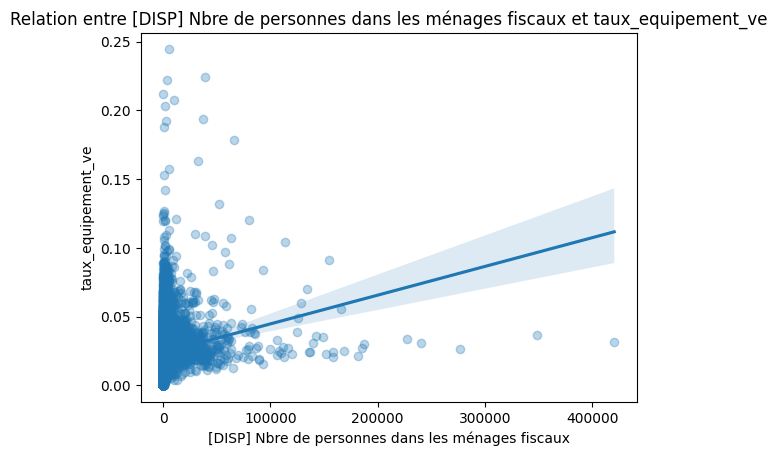

In [21]:
for col in num_cols:
    plt.figure()
    sns.regplot(x=df_imputation[col], y=df_imputation[target], scatter_kws={"alpha": 0.3})
    plt.title(f"Relation entre {col} et {target}")
    plt.show()

Nous pouvons constater quelques relations, comme Mediane et le taux d'équipement de véhicules électriques. En effet, une relation linéaire semble être envisageable.

Variables qualitatives vs cible

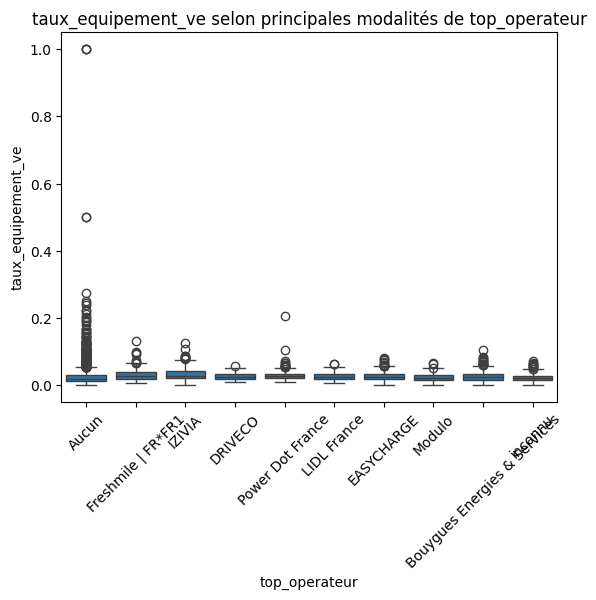

In [22]:
for col in cat_cols:
    top = df_imputation[col].value_counts().head(10).index
    df_temp = df_imputation[df_imputation[col].isin(top)]
    
    plt.figure()
    sns.boxplot(x=df_temp[col], y=df_temp[target])
    plt.title(f"{target} selon principales modalités de {col}")
    plt.xticks(rotation=45)
    plt.show()

### Corrélations

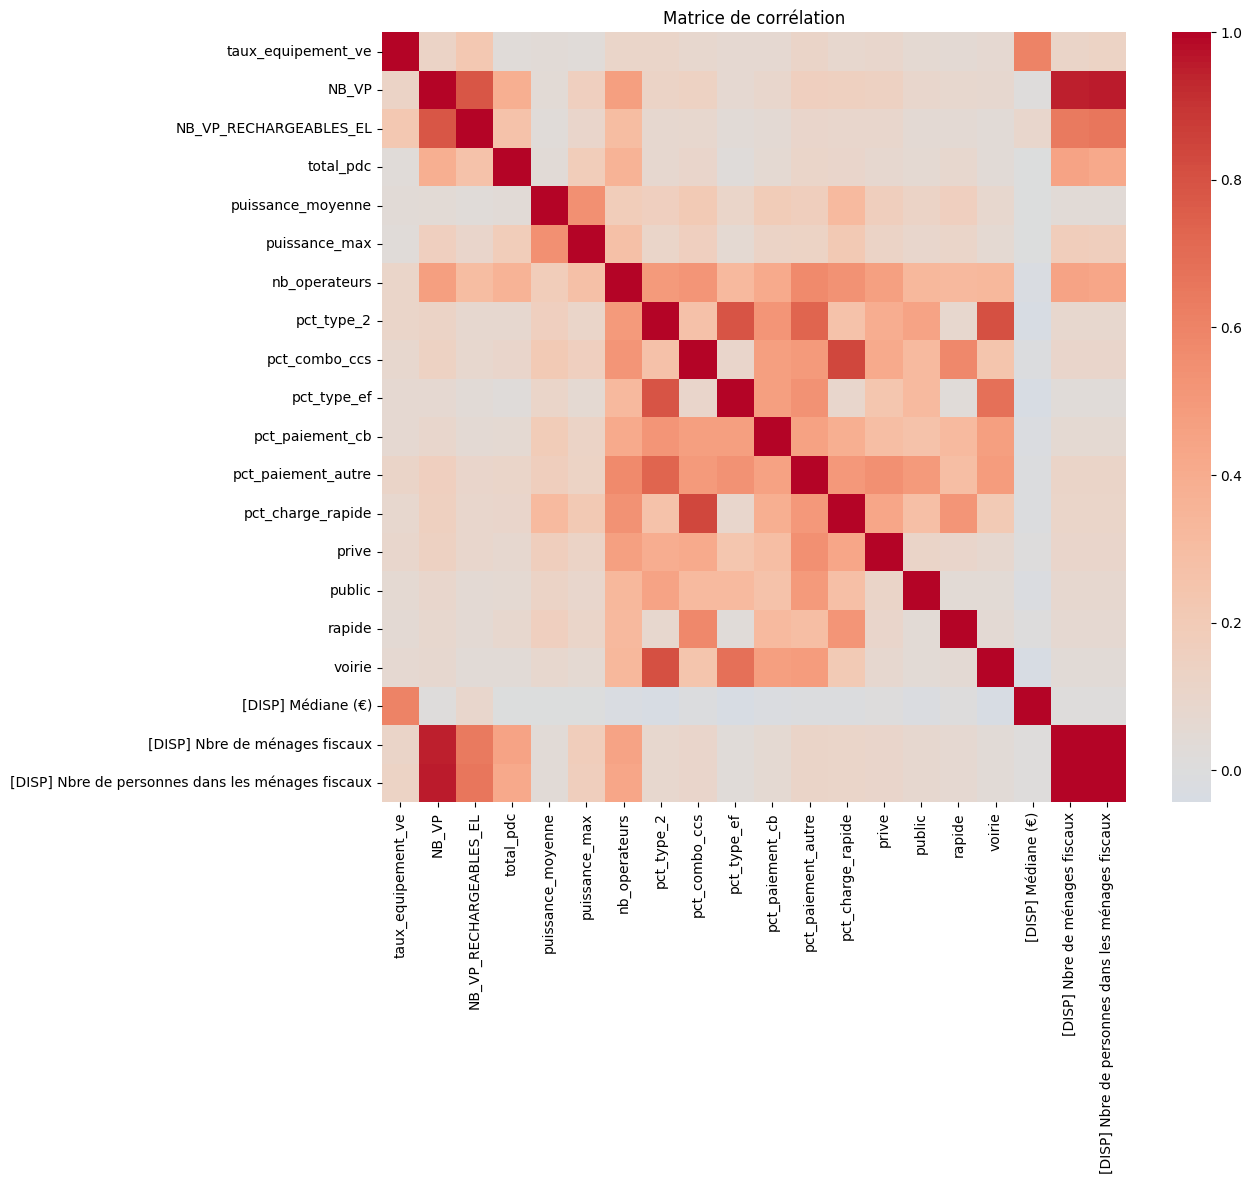

In [23]:
corr = df_imputation[[target] + num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

Ce que nous enseigne la matrice de corrélation :
Le taux VE dépend surtout :
- de la richesse ( plus une ville est riche, plus elle semble compter des VE )
- du volume de véhicules ( Plus une ville compte de véhicules, plus elle semble compter des VE )

Les infrastructures semblent peu expliquer directement, elles suivent la demande.

Des variables sont redondentes donc peuvent être éliminées.

Corrélations avec la cible

In [24]:
corr_target = corr[target].sort_values(ascending=False)
display(corr_target)

taux_equipement_ve                                   1.000000
[DISP] Médiane (€)                                   0.603772
NB_VP_RECHARGEABLES_EL                               0.222431
[DISP] Nbre de personnes dans les ménages fiscaux    0.128367
NB_VP                                                0.123340
[DISP] Nbre de ménages fiscaux                       0.116822
pct_paiement_autre                                   0.116803
nb_operateurs                                        0.108069
pct_type_2                                           0.105197
prive                                                0.089406
pct_combo_ccs                                        0.080660
pct_charge_rapide                                    0.078969
voirie                                               0.070126
pct_paiement_cb                                      0.066408
pct_type_ef                                          0.065548
public                                               0.059884
rapide  

Nous pouvons voir une forme d'explication avec certains groupes de variables comme celles socio démographiques. Un tri va être opéré pour une meilleure lisibilité.

Multicolinéarité

In [25]:
corr_expl = df_imputation[num_cols].corr().abs()

upper = corr_expl.where(np.triu(np.ones(corr_expl.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
    .sort_values("corr", ascending=False)
)

display(high_corr[high_corr["corr"] > 0.8])

,var1,var2,corr
341,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,0.993889
18,NB_VP,[DISP] Nbre de personnes dans les ménages fiscaux,0.952585
17,NB_VP,[DISP] Nbre de ménages fiscaux,0.945046
144,pct_combo_ccs,pct_charge_rapide,0.840922
129,pct_type_2,voirie,0.811926


Nous choisissons une variable représentative des groupes de variables mis en évidence :

In [26]:
vars_to_drop = [
    "NB_VP",
    "NB_VP_RECHARGEABLES_EL",
    "[DISP] Nbre de ménages fiscaux",
    "pct_type_2",
    "pct_type_ef",
    "part_charge_rapide"
]

df_clean = df_imputation.drop(columns=vars_to_drop, errors="ignore")

La variable cible étant construite comme un ratio entre le nombre de véhicules électriques et le nombre total de véhicules, les variables utilisées pour sa construction ont été exclues de l’analyse afin d’éviter tout biais de fuite d’information.
Leur inclusion aurait conduit à une relation mécanique avec la variable cible, faussant ainsi l’interprétation des résultats.

In [27]:
df_clean

,CODGEO,taux_equipement_ve,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_combo_ccs,pct_paiement_cb,pct_paiement_autre,pct_charge_rapide,top_operateur,prive,public,rapide,voirie,Libellé géographique,[DISP] Médiane (€),[DISP] Nbre de personnes dans les ménages fiscaux
0,1002,0.017483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1004,0.032214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1005,0.029488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1007,0.032400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1009,0.022075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,97612,0.003136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35202,97615,0.001649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35203,97699,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35204,97801,0.042105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Aucun,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [28]:
missing_pct = df_clean.isna().mean() * 100
display(missing_pct.sort_values(ascending=False))

[DISP] Médiane (€)                                   45.020735
[DISP] Nbre de personnes dans les ménages fiscaux    45.020735
Libellé géographique                                 39.248992
CODGEO                                                0.000000
taux_equipement_ve                                    0.000000
total_pdc                                             0.000000
pct_combo_ccs                                         0.000000
puissance_moyenne                                     0.000000
puissance_max                                         0.000000
nb_operateurs                                         0.000000
pct_charge_rapide                                     0.000000
pct_paiement_autre                                    0.000000
pct_paiement_cb                                       0.000000
top_operateur                                         0.000000
rapide                                                0.000000
public                                                0

In [29]:
df_clean.to_csv("data/df_clean.csv", index=False)